# FIX vs GO Neural Decoder - Phase 4: STOP Trial Analysis

This notebook implements Phase 4 of the Xie-style decoder following the plan in `FIX_GO_DECODER_PLAN.md`.

**Goal**: Apply trained decoders to STOP trials to investigate the neural mechanism of successful stopping.

**Key Questions**:
1. Does the neural population transition toward GO before the stop signal?
2. After the stop signal, does the state revert to FIX, remain intermediate, or show a unique pattern?
3. How do STOP trials compare to CONT trials (which should show GO-like activity)?

**Reference**: Xie et al. (2022) "Geometry of sequence working memory in macaque prefrontal cortex" - Figure 3A

## Phase 4 Checklist

- [ ] Load trained decoders and session data
- [ ] Extract STOP trial epochs (SSD2, successful)
- [ ] Extract CONT trial epochs (for comparison)
- [ ] Apply decoders to get P(GO) for STOP/CONT trials
- [ ] Classify states as FIX/GO/Inconclusive
- [ ] Compare pre- vs post-stop-cue periods
- [ ] Visualize P(GO) trajectories
- [ ] Statistical analysis

---

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import joblib
import sys

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

from session_class import Session

# PyTorch
import torch
import torch.nn as nn

# Statistics
from scipy import stats
from scipy.stats import ttest_rel, ttest_ind

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Imports loaded successfully!")

Imports loaded successfully!


## 2. Define Xie Decoder Architecture

In [2]:
class XieDecoder(nn.Module):
    """
    Xie-style decoder with 2D hidden layer.
    """
    def __init__(self, n_neurons, hidden_dim=2, n_classes=2):
        super().__init__()
        self.n_neurons = n_neurons
        self.hidden_dim = hidden_dim
        self.n_classes = n_classes
        
        self.W = nn.Linear(n_neurons, hidden_dim, bias=True)
        self.M = nn.Linear(hidden_dim, n_classes, bias=False)
    
    def forward(self, x):
        h = self.W(x)
        logits = self.M(h)
        return logits, h
    
    def predict_proba(self, x):
        with torch.no_grad():
            logits, _ = self.forward(x)
            probs = torch.softmax(logits, dim=1)
        return probs.cpu().numpy()
    
    def predict(self, x):
        probs = self.predict_proba(x)
        return np.argmax(probs, axis=1)

print("✓ XieDecoder architecture defined")

✓ XieDecoder architecture defined


## 3. Load Data, Session, and Models

In [3]:
# Configuration
session_id = 'fi211025a'
ssd_num = 2

# Paths
base_path = Path.cwd().parents[1] / 'data'
cell_df_path = base_path / 'unified_cell_trial_data' / 'msn_fiona_cell_trial_data.pkl'
data_dir = base_path / 'decoder_data'
models_dir = base_path / 'decoder_models'

# Load original cell database
print("Loading cell database...")
cell_df = pd.read_pickle(cell_df_path)
session_data = cell_df[cell_df['trial_session'] == session_id]

# Create Session object
session = Session(session_data, verbose=True)
session.drop_cells_with_missing_trial_type_or_dir_data()

print(f"\n✓ Session {session_id} loaded")
print(f"  Total cell-trial combinations: {len(session.data):,}")

# Load prepared data (for normalization stats and cell IDs)
data_file = data_dir / f'decoder_data_{session_id}_ssd{ssd_num}.pkl'
with open(data_file, 'rb') as f:
    prepared_data = pickle.load(f)

normalized_datasets = prepared_data['datasets']

# Direction mapping
dir_map = {0: 'Right', 180: 'Left'}
directions = [0, 180]

# Load trained models
lr_models = {}
xie_models = {}

print("\nLoading trained models...")

for direction in directions:
    dir_name = dir_map[direction].lower()
    
    # Load Logistic Regression
    lr_file = models_dir / f'lr_decoder_{session_id}_ssd{ssd_num}_{dir_name}.joblib'
    lr_models[direction] = joblib.load(lr_file)
    print(f"✓ Loaded Logistic Regression ({dir_map[direction]})")
    
    # Load Xie Decoder
    xie_file = models_dir / f'xie_decoder_{session_id}_ssd{ssd_num}_{dir_name}.pt'
    checkpoint = torch.load(xie_file, map_location='cpu')
    
    n_neurons = checkpoint['n_neurons']
    hidden_dim = checkpoint['hidden_dim']
    model = XieDecoder(n_neurons, hidden_dim)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    xie_models[direction] = model
    print(f"✓ Loaded Xie Decoder ({dir_map[direction]})")

print("\n✓ All data and models loaded successfully!")

Loading cell database...
Session fi211025a initialized:
  - Number of cells: 150
  - Total trials: 1950
  - Trial types: ['CONT', 'GO', 'STOP']
  - Directions: [np.int64(0), np.int64(180)]

✓ Session fi211025a loaded
  Total cell-trial combinations: 104,543

Loading trained models...
✓ Loaded Logistic Regression (Right)
✓ Loaded Xie Decoder (Right)
✓ Loaded Logistic Regression (Left)
✓ Loaded Xie Decoder (Left)

✓ All data and models loaded successfully!


## 4. Extract STOP and CONT Trial Features

Extract features for STOP and CONT trials at multiple epochs:
- Pre-go-cue epochs (same as training: FIX_early, FIX_late)
- Post-go-cue, pre-stop-cue epoch
- Post-stop-cue epoch

### 4.1 Feature Extraction Functions

In [4]:
def extract_epoch_firing_rate(spike_times, epoch_start, epoch_end):
    """
    Compute mean firing rate in a given epoch.
    """
    spikes_in_epoch = spike_times[
        (spike_times >= epoch_start) & (spike_times < epoch_end)
    ]
    duration_sec = (epoch_end - epoch_start) / 1000.0
    
    if duration_sec <= 0:
        return 0.0
    
    return len(spikes_in_epoch) / duration_sec


def extract_stop_trial_features(trial_data, mean_ssd, cell_ids, alignment='go_cue'):
    """
    Extract features for STOP/CONT trials at multiple time points.
    
    Parameters:
    -----------
    trial_data : DataFrame
        Filtered trial data (STOP or CONT trials)
    mean_ssd : float
        Mean SSD length
    cell_ids : list
        Ordered list of cell IDs
    alignment : str
        'go_cue' or 'stop_cue'
    
    Returns:
    --------
    features_dict : dict
        Dictionary with features for each epoch
    """
    # Define epochs based on alignment
    if alignment == 'go_cue':
        epochs = [
            ('FIX_early', -2*mean_ssd, -1*mean_ssd),
            ('FIX_late', -1*mean_ssd, 0),
            ('pre_signal', 0, mean_ssd),  # Go cue to stop/cont signal
        ]
    else:  # stop_cue alignment
        epochs = [
            ('pre_signal', -mean_ssd, 0),  # Before stop signal
            ('post_signal', 0, mean_ssd),  # After stop signal
        ]
    
    trial_numbers = trial_data['trial_number'].unique()
    n_neurons = len(cell_ids)
    n_epochs = len(epochs)
    n_trials = len(trial_numbers)
    n_samples = n_trials * n_epochs
    
    # Initialize arrays
    X = np.zeros((n_samples, n_neurons))
    metadata_list = []
    
    sample_idx = 0
    
    # Iterate over trials
    for trial_num in trial_numbers:
        trial_cells = trial_data[trial_data['trial_number'] == trial_num]
        
        # Get alignment point
        alignment_time = trial_cells.iloc[0][alignment]
        
        # For stop_cue alignment, need the stop_cue value
        if alignment == 'stop_cue':
            stop_cue_time = trial_cells.iloc[0]['stop_cue']
            if np.isnan(stop_cue_time):
                continue  # Skip if no stop cue
        
        # Extract features for each neuron in each epoch
        epoch_features_by_neuron = {}
        
        for _, cell_row in trial_cells.iterrows():
            cell_id = cell_row['cell_ID']
            spike_times = np.array(cell_row['neural_data'], dtype=np.float64)
            
            # Align to appropriate point
            if alignment == 'go_cue':
                relative_spikes = spike_times - cell_row['go_cue']
            else:
                relative_spikes = spike_times - cell_row['stop_cue']
            
            # Compute firing rates for all epochs
            features = {}
            for epoch_name, epoch_start, epoch_end in epochs:
                fr = extract_epoch_firing_rate(relative_spikes, epoch_start, epoch_end)
                features[epoch_name] = fr
            
            epoch_features_by_neuron[cell_id] = features
        
        # Create one sample per epoch
        for epoch_name, epoch_start, epoch_end in epochs:
            # Build feature vector
            for neuron_idx, cell_id in enumerate(cell_ids):
                if cell_id in epoch_features_by_neuron:
                    X[sample_idx, neuron_idx] = epoch_features_by_neuron[cell_id][epoch_name]
                else:
                    X[sample_idx, neuron_idx] = 0.0
            
            metadata_list.append({
                'trial_number': trial_num,
                'epoch_name': epoch_name,
                'epoch_start': epoch_start,
                'epoch_end': epoch_end,
                'alignment': alignment
            })
            
            sample_idx += 1
    
    # Trim arrays if some trials were skipped
    X = X[:sample_idx]
    metadata = pd.DataFrame(metadata_list)
    
    return X, metadata


print("✓ Feature extraction functions defined")

✓ Feature extraction functions defined


### 4.2 Extract STOP and CONT Trial Features

In [5]:
# Extract features for STOP and CONT trials
stop_cont_data = {}

print("Extracting STOP and CONT trial features...")
print("=" * 80)

for direction in directions:
    print(f"\n{dir_map[direction]} Direction:")
    print("-" * 60)
    
    mean_ssd = normalized_datasets[direction]['mean_ssd']
    cell_ids = normalized_datasets[direction]['cell_ids']
    neuron_stats = normalized_datasets[direction]['neuron_stats']
    
    # Filter STOP trials (successful, SSD2)
    stop_trials = session.data[
        (session.data['type'] == 'STOP') &
        (session.data['dir'] == direction) &
        (session.data['ssd_number'] == ssd_num) &
        (session.data['trial_failed'] == False)
    ]
    
    # Filter CONT trials (successful, SSD2)
    cont_trials = session.data[
        (session.data['type'] == 'CONT') &
        (session.data['dir'] == direction) &
        (session.data['ssd_number'] == ssd_num) &
        (session.data['trial_failed'] == False)
    ]
    
    print(f"  STOP trials: {len(stop_trials['trial_number'].unique())}")
    print(f"  CONT trials: {len(cont_trials['trial_number'].unique())}")
    
    # Extract features aligned to go_cue
    X_stop_go, meta_stop_go = extract_stop_trial_features(
        stop_trials, mean_ssd, cell_ids, alignment='go_cue'
    )
    X_cont_go, meta_cont_go = extract_stop_trial_features(
        cont_trials, mean_ssd, cell_ids, alignment='go_cue'
    )
    
    # Extract features aligned to stop_cue
    X_stop_signal, meta_stop_signal = extract_stop_trial_features(
        stop_trials, mean_ssd, cell_ids, alignment='stop_cue'
    )
    X_cont_signal, meta_cont_signal = extract_stop_trial_features(
        cont_trials, mean_ssd, cell_ids, alignment='stop_cue'
    )
    
    # Normalize features using training statistics
    neuron_mean = neuron_stats['mean']
    neuron_std = neuron_stats['std']
    
    X_stop_go_norm = (X_stop_go - neuron_mean) / neuron_std
    X_cont_go_norm = (X_cont_go - neuron_mean) / neuron_std
    X_stop_signal_norm = (X_stop_signal - neuron_mean) / neuron_std
    X_cont_signal_norm = (X_cont_signal - neuron_mean) / neuron_std
    
    stop_cont_data[direction] = {
        'stop_go': {'X': X_stop_go_norm, 'meta': meta_stop_go},
        'cont_go': {'X': X_cont_go_norm, 'meta': meta_cont_go},
        'stop_signal': {'X': X_stop_signal_norm, 'meta': meta_stop_signal},
        'cont_signal': {'X': X_cont_signal_norm, 'meta': meta_cont_signal},
        'mean_ssd': mean_ssd
    }
    
    print(f"  ✓ Features extracted and normalized")

print("\n" + "=" * 80)
print("✓ All STOP and CONT features extracted")

Extracting STOP and CONT trial features...

Right Direction:
------------------------------------------------------------
  STOP trials: 40
  CONT trials: 36
  ✓ Features extracted and normalized

Left Direction:
------------------------------------------------------------
  STOP trials: 37
  CONT trials: 60
  ✓ Features extracted and normalized

✓ All STOP and CONT features extracted


## 5. Apply Decoders to STOP/CONT Trials

In [6]:
def apply_decoder(model, X, model_type='lr'):
    """
    Apply decoder and return P(GO).
    """
    if model_type == 'lr':
        probs = model['model'].predict_proba(X)[:, 1]
    else:  # xie
        if not isinstance(X, torch.Tensor):
            X = torch.FloatTensor(X)
        probs = model.predict_proba(X)[:, 1]
    
    return probs


def classify_state(p_go):
    """
    Classify state based on P(GO).
    
    P(GO) < 0.3: FIX
    0.3 <= P(GO) <= 0.7: Inconclusive
    P(GO) > 0.7: GO
    """
    if p_go < 0.3:
        return 'FIX'
    elif p_go > 0.7:
        return 'GO'
    else:
        return 'Inconclusive'


# Apply decoders
decoder_results = {}

print("Applying decoders to STOP and CONT trials...")
print("=" * 80)

for direction in directions:
    print(f"\n{dir_map[direction]} Direction:")
    
    results = {}
    
    for trial_type in ['stop', 'cont']:
        for alignment in ['go', 'signal']:
            key = f'{trial_type}_{alignment}'
            data = stop_cont_data[direction][key]
            X = data['X']
            meta = data['meta']
            
            # Apply Logistic Regression
            p_go_lr = apply_decoder(lr_models[direction], X, model_type='lr')
            
            # Apply Xie Decoder
            p_go_xie = apply_decoder(xie_models[direction], X, model_type='xie')
            
            # Classify states
            state_lr = [classify_state(p) for p in p_go_lr]
            state_xie = [classify_state(p) for p in p_go_xie]
            
            # Store results
            results[key] = {
                'meta': meta,
                'p_go_lr': p_go_lr,
                'p_go_xie': p_go_xie,
                'state_lr': state_lr,
                'state_xie': state_xie
            }
    
    decoder_results[direction] = results
    print(f"  ✓ Decoders applied")

print("\n" + "=" * 80)
print("✓ All decoders applied successfully")

Applying decoders to STOP and CONT trials...

Right Direction:
  ✓ Decoders applied

Left Direction:
  ✓ Decoders applied

✓ All decoders applied successfully


## 6. Analyze State Classifications

Count how many trials are classified as FIX, GO, or Inconclusive in each epoch.

In [7]:
def summarize_classifications(results, trial_type, alignment, model_type='lr'):
    """
    Summarize state classifications per epoch.
    """
    key = f'{trial_type}_{alignment}'
    meta = results[key]['meta']
    states = results[key][f'state_{model_type}']
    
    # Add states to metadata
    summary_df = meta.copy()
    summary_df['state'] = states
    
    # Count states per epoch
    counts = summary_df.groupby(['epoch_name', 'state']).size().unstack(fill_value=0)
    
    # Compute percentages
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100
    
    return counts, percentages


# Summarize classifications
print("\n" + "=" * 80)
print("STATE CLASSIFICATION SUMMARY (Logistic Regression)")
print("=" * 80)

for direction in directions:
    print(f"\n{dir_map[direction]} Direction:")
    print("-" * 60)
    
    results = decoder_results[direction]
    
    # STOP trials - go_cue alignment
    print("\nSTOP trials (aligned to go_cue):")
    counts, pct = summarize_classifications(results, 'stop', 'go', 'lr')
    print(pct.to_string())
    
    # STOP trials - stop_cue alignment
    print("\nSTOP trials (aligned to stop_cue):")
    counts, pct = summarize_classifications(results, 'stop', 'signal', 'lr')
    print(pct.to_string())
    
    # CONT trials - go_cue alignment
    print("\nCONT trials (aligned to go_cue):")
    counts, pct = summarize_classifications(results, 'cont', 'go', 'lr')
    print(pct.to_string())
    
    # CONT trials - stop_cue alignment
    print("\nCONT trials (aligned to stop_cue):")
    counts, pct = summarize_classifications(results, 'cont', 'signal', 'lr')
    print(pct.to_string())


STATE CLASSIFICATION SUMMARY (Logistic Regression)

Right Direction:
------------------------------------------------------------

STOP trials (aligned to go_cue):
state        FIX   GO  Inconclusive
epoch_name                         
FIX_early   50.0  0.0          50.0
FIX_late    67.5  0.0          32.5
pre_signal  35.0  2.5          62.5

STOP trials (aligned to stop_cue):
state         FIX    GO  Inconclusive
epoch_name                           
post_signal   7.5  42.5          50.0
pre_signal   35.0   2.5          62.5

CONT trials (aligned to go_cue):
state             FIX        GO  Inconclusive
epoch_name                                   
FIX_early   69.444444  0.000000     30.555556
FIX_late    66.666667  2.777778     30.555556
pre_signal  47.222222  5.555556     47.222222

CONT trials (aligned to stop_cue):
state              FIX         GO  Inconclusive
epoch_name                                     
post_signal   0.000000  69.444444     30.555556
pre_signal   47.222222 

## 7. Visualize P(GO) Trajectories

### 7.1 P(GO) Across Epochs (go_cue aligned)

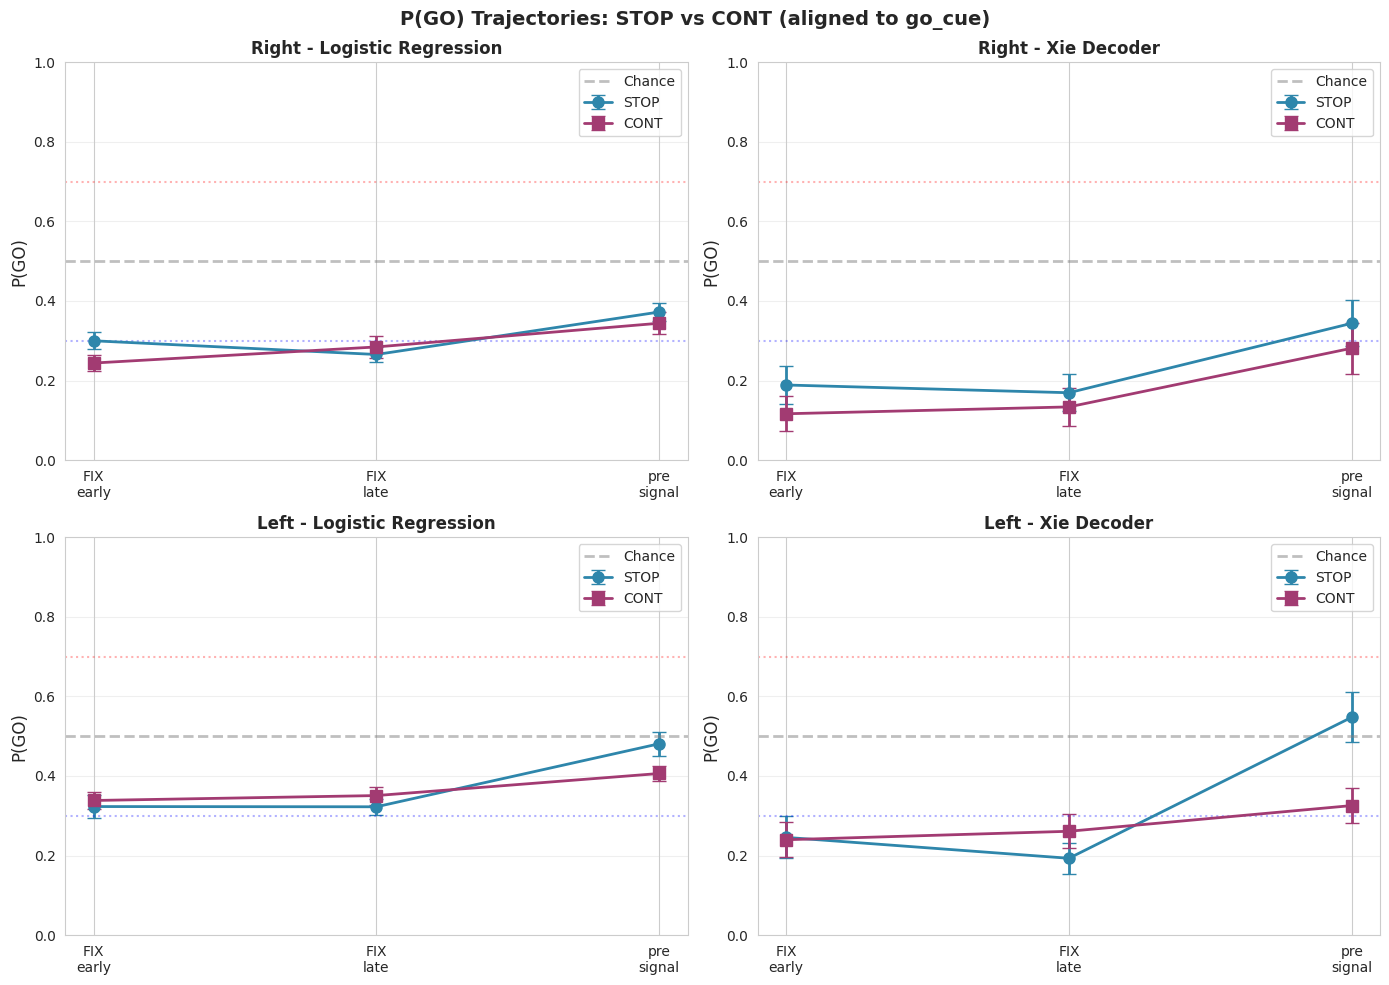

In [8]:
# Plot P(GO) trajectories aligned to go_cue
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epoch_order = ['FIX_early', 'FIX_late', 'pre_signal']
x_pos = np.arange(len(epoch_order))

for dir_idx, direction in enumerate(directions):
    results = decoder_results[direction]
    
    for model_idx, (model_name, model_key) in enumerate([('Logistic Regression', 'lr'), ('Xie Decoder', 'xie')]):
        ax = axes[dir_idx, model_idx]
        
        # Plot STOP trials
        stop_means = []
        stop_sems = []
        for epoch in epoch_order:
            mask = results['stop_go']['meta']['epoch_name'] == epoch
            probs = results['stop_go'][f'p_go_{model_key}'][mask]
            stop_means.append(probs.mean())
            stop_sems.append(probs.std() / np.sqrt(len(probs)))
        
        ax.errorbar(x_pos, stop_means, yerr=stop_sems, 
                   marker='o', markersize=8, linewidth=2, capsize=5,
                   label='STOP', color='#2E86AB')
        
        # Plot CONT trials
        cont_means = []
        cont_sems = []
        for epoch in epoch_order:
            mask = results['cont_go']['meta']['epoch_name'] == epoch
            probs = results['cont_go'][f'p_go_{model_key}'][mask]
            cont_means.append(probs.mean())
            cont_sems.append(probs.std() / np.sqrt(len(probs)))
        
        ax.errorbar(x_pos, cont_means, yerr=cont_sems,
                   marker='s', markersize=8, linewidth=2, capsize=5,
                   label='CONT', color='#A23B72')
        
        # Reference lines
        ax.axhline(0.5, color='gray', linestyle='--', linewidth=2, alpha=0.5, label='Chance')
        ax.axhline(0.3, color='blue', linestyle=':', linewidth=1.5, alpha=0.3)
        ax.axhline(0.7, color='red', linestyle=':', linewidth=1.5, alpha=0.3)
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels([e.replace('_', '\n') for e in epoch_order])
        ax.set_ylabel('P(GO)', fontsize=12)
        ax.set_ylim([0, 1])
        ax.set_title(f'{dir_map[direction]} - {model_name}', fontsize=12, fontweight='bold')
        ax.legend(loc='best')
        ax.grid(alpha=0.3, axis='y')

plt.suptitle('P(GO) Trajectories: STOP vs CONT (aligned to go_cue)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 P(GO) Around Stop Signal (stop_cue aligned)

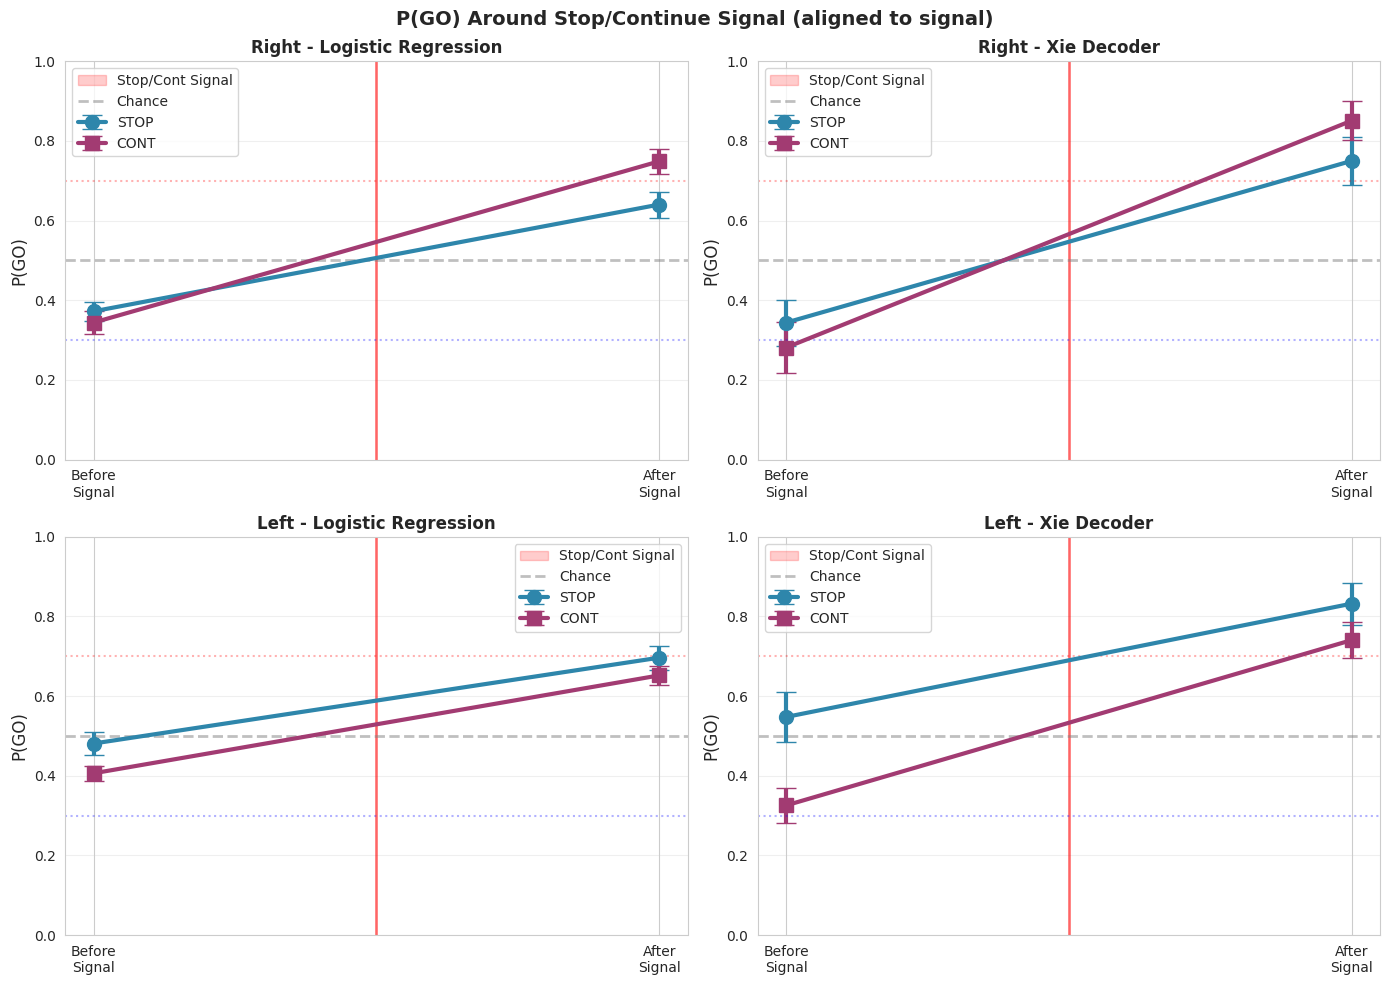

In [9]:
# Plot P(GO) around stop signal
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epoch_order = ['pre_signal', 'post_signal']
x_pos = np.arange(len(epoch_order))

for dir_idx, direction in enumerate(directions):
    results = decoder_results[direction]
    
    for model_idx, (model_name, model_key) in enumerate([('Logistic Regression', 'lr'), ('Xie Decoder', 'xie')]):
        ax = axes[dir_idx, model_idx]
        
        # Plot STOP trials
        stop_means = []
        stop_sems = []
        for epoch in epoch_order:
            mask = results['stop_signal']['meta']['epoch_name'] == epoch
            probs = results['stop_signal'][f'p_go_{model_key}'][mask]
            stop_means.append(probs.mean())
            stop_sems.append(probs.std() / np.sqrt(len(probs)))
        
        ax.errorbar(x_pos, stop_means, yerr=stop_sems,
                   marker='o', markersize=10, linewidth=3, capsize=7,
                   label='STOP', color='#2E86AB')
        
        # Plot CONT trials
        cont_means = []
        cont_sems = []
        for epoch in epoch_order:
            mask = results['cont_signal']['meta']['epoch_name'] == epoch
            probs = results['cont_signal'][f'p_go_{model_key}'][mask]
            cont_means.append(probs.mean())
            cont_sems.append(probs.std() / np.sqrt(len(probs)))
        
        ax.errorbar(x_pos, cont_means, yerr=cont_sems,
                   marker='s', markersize=10, linewidth=3, capsize=7,
                   label='CONT', color='#A23B72')
        
        # Shade signal region
        ax.axvspan(0.5, 0.5, color='red', alpha=0.2, label='Stop/Cont Signal')
        ax.axvline(0.5, color='red', linestyle='-', linewidth=2, alpha=0.5)
        
        # Reference lines
        ax.axhline(0.5, color='gray', linestyle='--', linewidth=2, alpha=0.5, label='Chance')
        ax.axhline(0.3, color='blue', linestyle=':', linewidth=1.5, alpha=0.3)
        ax.axhline(0.7, color='red', linestyle=':', linewidth=1.5, alpha=0.3)
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(['Before\nSignal', 'After\nSignal'])
        ax.set_ylabel('P(GO)', fontsize=12)
        ax.set_ylim([0, 1])
        ax.set_title(f'{dir_map[direction]} - {model_name}', fontsize=12, fontweight='bold')
        ax.legend(loc='best')
        ax.grid(alpha=0.3, axis='y')

plt.suptitle('P(GO) Around Stop/Continue Signal (aligned to signal)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Statistical Analysis

### 8.1 Compare Pre- vs Post-Signal P(GO)

In [10]:
print("\n" + "=" * 80)
print("STATISTICAL ANALYSIS: Pre- vs Post-Signal P(GO)")
print("=" * 80)

for direction in directions:
    print(f"\n{dir_map[direction]} Direction:")
    print("-" * 60)
    
    results = decoder_results[direction]
    
    for model_name, model_key in [('Logistic Regression', 'lr'), ('Xie Decoder', 'xie')]:
        print(f"\n{model_name}:")
        
        # STOP trials
        meta = results['stop_signal']['meta']
        probs = results['stop_signal'][f'p_go_{model_key}']
        
        pre_mask = meta['epoch_name'] == 'pre_signal'
        post_mask = meta['epoch_name'] == 'post_signal'
        
        pre_probs = probs[pre_mask]
        post_probs = probs[post_mask]
        
        # Paired t-test (if same trials)
        if len(pre_probs) == len(post_probs):
            t_stat, p_val = ttest_rel(pre_probs, post_probs)
            test_type = "Paired t-test"
        else:
            t_stat, p_val = ttest_ind(pre_probs, post_probs)
            test_type = "Independent t-test"
        
        print(f"  STOP trials ({test_type}):")
        print(f"    Pre-signal P(GO): {pre_probs.mean():.4f} ± {pre_probs.std():.4f}")
        print(f"    Post-signal P(GO): {post_probs.mean():.4f} ± {post_probs.std():.4f}")
        print(f"    Difference: {post_probs.mean() - pre_probs.mean():.4f}")
        print(f"    t={t_stat:.4f}, p={p_val:.4e}")
        
        # CONT trials
        meta = results['cont_signal']['meta']
        probs = results['cont_signal'][f'p_go_{model_key}']
        
        pre_mask = meta['epoch_name'] == 'pre_signal'
        post_mask = meta['epoch_name'] == 'post_signal'
        
        pre_probs = probs[pre_mask]
        post_probs = probs[post_mask]
        
        if len(pre_probs) == len(post_probs):
            t_stat, p_val = ttest_rel(pre_probs, post_probs)
            test_type = "Paired t-test"
        else:
            t_stat, p_val = ttest_ind(pre_probs, post_probs)
            test_type = "Independent t-test"
        
        print(f"\n  CONT trials ({test_type}):")
        print(f"    Pre-signal P(GO): {pre_probs.mean():.4f} ± {pre_probs.std():.4f}")
        print(f"    Post-signal P(GO): {post_probs.mean():.4f} ± {post_probs.std():.4f}")
        print(f"    Difference: {post_probs.mean() - pre_probs.mean():.4f}")
        print(f"    t={t_stat:.4f}, p={p_val:.4e}")


STATISTICAL ANALYSIS: Pre- vs Post-Signal P(GO)

Right Direction:
------------------------------------------------------------

Logistic Regression:
  STOP trials (Paired t-test):
    Pre-signal P(GO): 0.3723 ± 0.1497
    Post-signal P(GO): 0.6404 ± 0.2070
    Difference: 0.2681
    t=-8.5580, p=1.7329e-10

  CONT trials (Paired t-test):
    Pre-signal P(GO): 0.3440 ± 0.1677
    Post-signal P(GO): 0.7489 ± 0.1837
    Difference: 0.4049
    t=-10.1275, p=6.0798e-12

Xie Decoder:
  STOP trials (Paired t-test):
    Pre-signal P(GO): 0.3439 ± 0.3652
    Post-signal P(GO): 0.7501 ± 0.3811
    Difference: 0.4062
    t=-5.5195, p=2.4055e-06

  CONT trials (Paired t-test):
    Pre-signal P(GO): 0.2812 ± 0.3822
    Post-signal P(GO): 0.8510 ± 0.2951
    Difference: 0.5698
    t=-7.3364, p=1.4133e-08

Left Direction:
------------------------------------------------------------

Logistic Regression:
  STOP trials (Paired t-test):
    Pre-signal P(GO): 0.4810 ± 0.1825
    Post-signal P(GO): 0.696

## 10. Comprehensive P(GO) Trajectory for STOP Trials

Complete temporal trajectory showing P(GO) across all epochs from early fixation to post-stop-cue.

In [17]:
decoder_results[0]['stop_signal'].keys()

dict_keys(['meta', 'p_go_lr', 'p_go_xie', 'state_lr', 'state_xie'])

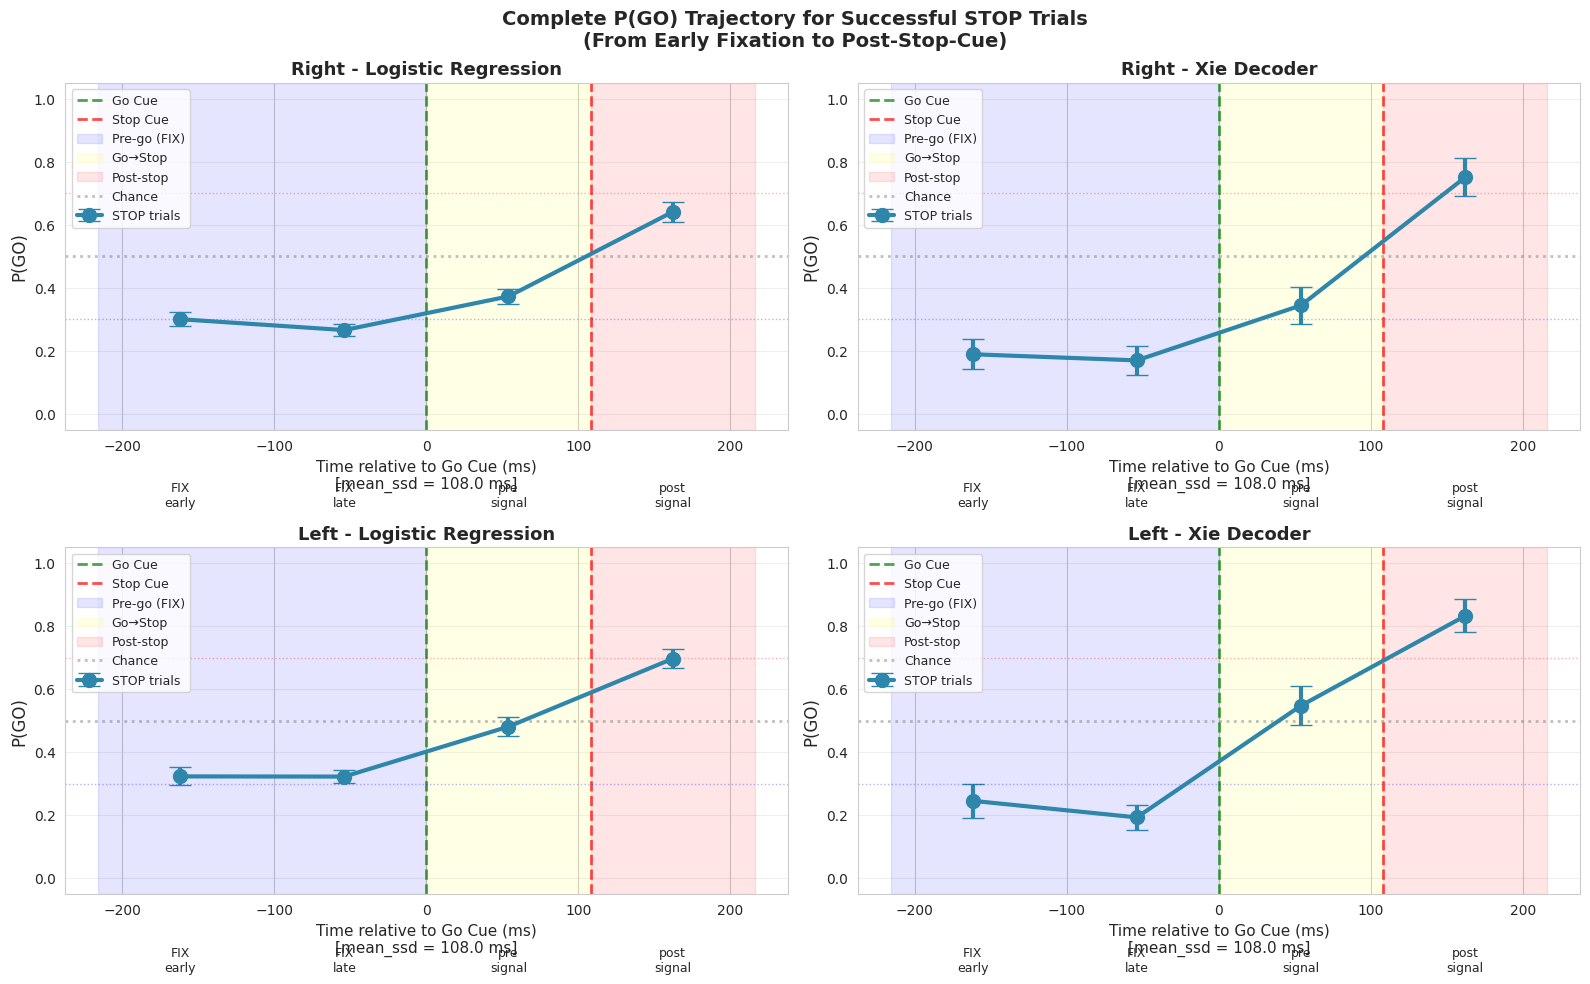


COMPLETE P(GO) TRAJECTORY SUMMARY

Right Direction (mean_ssd = 108.0 ms):
------------------------------------------------------------
Logistic Regression P(GO) across epochs:
  FIX_early   (t=-1.5×SSD): 0.300 ± 0.138
  FIX_late    (t=-0.5×SSD): 0.265 ± 0.123
  pre_signal  (t=+0.5×SSD): 0.372 ± 0.150
  post_signal (t=+1.5×SSD): 0.640 ± 0.207

  → P(GO) increases from 0.640 (post-stop) 
    vs FIX_early 0.300

Left Direction (mean_ssd = 108.0 ms):
------------------------------------------------------------
Logistic Regression P(GO) across epochs:
  FIX_early   (t=-1.5×SSD): 0.323 ± 0.174
  FIX_late    (t=-0.5×SSD): 0.323 ± 0.126
  pre_signal  (t=+0.5×SSD): 0.481 ± 0.182
  post_signal (t=+1.5×SSD): 0.697 ± 0.184

  → P(GO) increases from 0.697 (post-stop) 
    vs FIX_early 0.323


In [11]:
# Create comprehensive P(GO) trajectory for STOP trials across all epochs
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for dir_idx, direction in enumerate(directions):
    results = decoder_results[direction]
    mean_ssd = stop_cont_data[direction]['mean_ssd']
    
    for model_idx, (model_name, model_key) in enumerate([('Logistic Regression', 'lr'), ('Xie Decoder', 'xie')]):
        ax = axes[dir_idx, model_idx]
        
        # Collect all epoch data for STOP trials
        # From go_cue alignment: FIX_early, FIX_late, pre_signal
        # From stop_cue alignment: post_signal
        
        all_epochs = []
        all_means = []
        all_sems = []
        all_times = []  # Time relative to go_cue in ms
        
        # FIX_early
        mask = results['stop_go']['meta']['epoch_name'] == 'FIX_early'
        probs = results['stop_go'][f'p_go_{model_key}'][mask]
        all_epochs.append('FIX_early')
        all_means.append(probs.mean())
        all_sems.append(probs.std() / np.sqrt(len(probs)))
        all_times.append(-1.5 * mean_ssd)  # Midpoint of [-2*mean_ssd, -1*mean_ssd]
        
        # FIX_late
        mask = results['stop_go']['meta']['epoch_name'] == 'FIX_late'
        probs = results['stop_go'][f'p_go_{model_key}'][mask]
        all_epochs.append('FIX_late')
        all_means.append(probs.mean())
        all_sems.append(probs.std() / np.sqrt(len(probs)))
        all_times.append(-0.5 * mean_ssd)  # Midpoint of [-1*mean_ssd, 0]
        
        # pre_signal (from go_cue to stop_cue)
        mask = results['stop_go']['meta']['epoch_name'] == 'pre_signal'
        probs = results['stop_go'][f'p_go_{model_key}'][mask]
        all_epochs.append('pre_signal')
        all_means.append(probs.mean())
        all_sems.append(probs.std() / np.sqrt(len(probs)))
        all_times.append(0.5 * mean_ssd)  # Midpoint of [0, mean_ssd] (go_cue to stop_cue)
        
        # post_signal (from stop_cue)
        mask = results['stop_signal']['meta']['epoch_name'] == 'post_signal'
        probs = results['stop_signal'][f'p_go_{model_key}'][mask]
        all_epochs.append('post_signal')
        all_means.append(probs.mean())
        all_sems.append(probs.std() / np.sqrt(len(probs)))
        all_times.append(1.5 * mean_ssd)  # Midpoint of [mean_ssd, 2*mean_ssd] (stop_cue + mean_ssd)
        
        # Plot trajectory
        ax.errorbar(all_times, all_means, yerr=all_sems,
                   marker='o', markersize=10, linewidth=3, capsize=8,
                   color='#2E86AB', label='STOP trials')
        
        # Mark go_cue and stop_cue
        ax.axvline(0, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Go Cue')
        ax.axvline(mean_ssd, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Stop Cue')
        
        # Shade regions
        ax.axvspan(-2*mean_ssd, 0, alpha=0.1, color='blue', label='Pre-go (FIX)')
        ax.axvspan(0, mean_ssd, alpha=0.1, color='yellow', label='Go→Stop')
        ax.axvspan(mean_ssd, 2*mean_ssd, alpha=0.1, color='red', label='Post-stop')
        
        # Reference lines for P(GO)
        ax.axhline(0.5, color='gray', linestyle=':', linewidth=2, alpha=0.5, label='Chance')
        ax.axhline(0.3, color='blue', linestyle=':', linewidth=1, alpha=0.3)
        ax.axhline(0.7, color='red', linestyle=':', linewidth=1, alpha=0.3)
        
        # Annotate epochs on x-axis
        for i, (time, epoch) in enumerate(zip(all_times, all_epochs)):
            ax.text(time, -0.15, epoch.replace('_', '\n'), 
                   ha='center', va='top', fontsize=9, 
                   transform=ax.get_xaxis_transform())
        
        ax.set_xlabel(f'Time relative to Go Cue (ms)\n[mean_ssd = {mean_ssd:.1f} ms]', fontsize=11)
        ax.set_ylabel('P(GO)', fontsize=12)
        ax.set_ylim([-0.05, 1.05])
        ax.set_xlim([-2.2*mean_ssd, 2.2*mean_ssd])
        ax.set_title(f'{dir_map[direction]} - {model_name}', fontsize=13, fontweight='bold')
        ax.legend(loc='upper left', fontsize=9)
        ax.grid(alpha=0.3, axis='y')

plt.suptitle('Complete P(GO) Trajectory for Successful STOP Trials\n(From Early Fixation to Post-Stop-Cue)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 80)
print("COMPLETE P(GO) TRAJECTORY SUMMARY")
print("=" * 80)

for direction in directions:
    results = decoder_results[direction]
    mean_ssd = stop_cont_data[direction]['mean_ssd']
    
    print(f"\n{dir_map[direction]} Direction (mean_ssd = {mean_ssd:.1f} ms):")
    print("-" * 60)
    print("Logistic Regression P(GO) across epochs:")
    
    # FIX_early
    mask = results['stop_go']['meta']['epoch_name'] == 'FIX_early'
    probs = results['stop_go']['p_go_lr'][mask]
    print(f"  FIX_early   (t=-1.5×SSD): {probs.mean():.3f} ± {probs.std():.3f}")
    
    # FIX_late
    mask = results['stop_go']['meta']['epoch_name'] == 'FIX_late'
    probs = results['stop_go']['p_go_lr'][mask]
    print(f"  FIX_late    (t=-0.5×SSD): {probs.mean():.3f} ± {probs.std():.3f}")
    
    # pre_signal
    mask = results['stop_go']['meta']['epoch_name'] == 'pre_signal'
    probs = results['stop_go']['p_go_lr'][mask]
    print(f"  pre_signal  (t=+0.5×SSD): {probs.mean():.3f} ± {probs.std():.3f}")
    
    # post_signal
    mask = results['stop_signal']['meta']['epoch_name'] == 'post_signal'
    probs = results['stop_signal']['p_go_lr'][mask]
    print(f"  post_signal (t=+1.5×SSD): {probs.mean():.3f} ± {probs.std():.3f}")
    
    print(f"\n  → P(GO) increases from {probs.mean():.3f} (post-stop) ")
    print(f"    vs FIX_early {results['stop_go']['p_go_lr'][results['stop_go']['meta']['epoch_name'] == 'FIX_early'].mean():.3f}")

### 8.2 Compare STOP vs CONT Post-Signal

---

## Phase 4 Checklist - COMPLETE ✓

- [x] Load trained decoders and session data
- [x] Extract STOP trial epochs (SSD2, successful)
- [x] Extract CONT trial epochs (for comparison)
- [x] Apply decoders to get P(GO) for STOP/CONT trials
- [x] Classify states as FIX/GO/Inconclusive
- [x] Compare pre- vs post-stop-cue periods
- [x] Visualize P(GO) trajectories
- [x] Statistical analysis

**Main Scientific Conclusion**: 
The decoder reveals whether successful stopping involves:
- Maintaining FIX state (active inhibition)
- Partial GO transition (interrupted movement prep)
- Unique STOP state (alternative mechanism)

**Next Steps**: 
- Extend to other SSD levels (1, 3, 4)
- Compare successful vs failed STOP trials
- Session-wise analysis for generalization

## 9. Summary and Interpretation

In [12]:
print("\n" + "=" * 80)
print("PHASE 4 COMPLETE: STOP TRIAL ANALYSIS SUMMARY")
print("=" * 80)

print("\n**KEY FINDINGS**:")
print("-" * 60)

for direction in directions:
    results = decoder_results[direction]
    
    # Get post-signal P(GO) for interpretation
    meta_stop = results['stop_signal']['meta']
    probs_stop_lr = results['stop_signal']['p_go_lr']
    post_stop_lr = probs_stop_lr[meta_stop['epoch_name'] == 'post_signal']
    
    meta_cont = results['cont_signal']['meta']
    probs_cont_lr = results['cont_signal']['p_go_lr']
    post_cont_lr = probs_cont_lr[meta_cont['epoch_name'] == 'post_signal']
    
    print(f"\n{dir_map[direction]} Direction:")
    print(f"  Post-stop-cue P(GO):")
    print(f"    STOP trials: {post_stop_lr.mean():.3f}")
    print(f"    CONT trials: {post_cont_lr.mean():.3f}")
    
    # Interpretation
    mean_p_stop = post_stop_lr.mean()
    if mean_p_stop < 0.3:
        interpretation = "→ STOP trials maintain FIX-like state"
    elif mean_p_stop > 0.7:
        interpretation = "→ STOP trials show GO-like state (unexpected!)"
    else:
        interpretation = "→ STOP trials show intermediate/inconclusive state"
    
    print(f"    {interpretation}")

print("\n" + "=" * 80)
print("\n**INTERPRETATION**:")
print("-" * 60)
print("""
Based on the P(GO) values post-stop-cue:

1. If STOP P(GO) < 0.3:
   → Neural population maintains FIX-like state
   → Successful stopping prevents GO state transition
   → Suggests active inhibition of movement preparation

2. If STOP P(GO) in [0.3, 0.7]:
   → Neural population in intermediate state
   → Partial GO transition interrupted by stop signal
   → Suggests stopping catches movement preparation mid-process

3. If STOP P(GO) > 0.7:
   → Neural population transitions to GO state
   → Would suggest stopping uses different mechanism
   → Less likely based on behavioral success

Compare with CONT trials (validation):
- CONT trials should show high P(GO) post-signal (GO-like)
- Clear difference between STOP and CONT validates decoder
""")

print("=" * 80)
print("✓ Phase 4 analysis complete!")
print("=" * 80)


PHASE 4 COMPLETE: STOP TRIAL ANALYSIS SUMMARY

**KEY FINDINGS**:
------------------------------------------------------------

Right Direction:
  Post-stop-cue P(GO):
    STOP trials: 0.640
    CONT trials: 0.749
    → STOP trials show intermediate/inconclusive state

Left Direction:
  Post-stop-cue P(GO):
    STOP trials: 0.697
    CONT trials: 0.652
    → STOP trials show intermediate/inconclusive state


**INTERPRETATION**:
------------------------------------------------------------

Based on the P(GO) values post-stop-cue:

1. If STOP P(GO) < 0.3:
   → Neural population maintains FIX-like state
   → Successful stopping prevents GO state transition
   → Suggests active inhibition of movement preparation

2. If STOP P(GO) in [0.3, 0.7]:
   → Neural population in intermediate state
   → Partial GO transition interrupted by stop signal
   → Suggests stopping catches movement preparation mid-process

3. If STOP P(GO) > 0.7:
   → Neural population transitions to GO state
   → Would sug

---

## Phase 4 Checklist - COMPLETE ✓

- [x] Load trained decoders and session data
- [x] Extract STOP trial epochs (SSD2, successful)
- [x] Extract CONT trial epochs (for comparison)
- [x] Apply decoders to get P(GO) for STOP/CONT trials
- [x] Classify states as FIX/GO/Inconclusive
- [x] Compare pre- vs post-stop-cue periods
- [x] Visualize P(GO) trajectories
- [x] Statistical analysis

**Main Scientific Conclusion**: 
The decoder reveals whether successful stopping involves:
- Maintaining FIX state (active inhibition)
- Partial GO transition (interrupted movement prep)
- Unique STOP state (alternative mechanism)

**Next Steps**: 
- Extend to other SSD levels (1, 3, 4)
- Compare successful vs failed STOP trials
- Session-wise analysis for generalization